# Vacuum Distillation with `difflow_refinery`

A vacuum distillation unit (VDU) takes the atmospheric residue from the crude
column and splits it into light and heavy vacuum gas oil (LVGO, HVGO), slop and
vacuum residue. Moving the VGO/residue cut point is one of the larger margin
levers in a refinery, and VGO quality sets the conversion unit's feed. So a
planning model needs the VDU as a function with a derivative.

This notebook chains an assay through the column:

1. characterize a crude into pseudocomponents, including the heavy end past 565 C;
2. take the atmospheric residue (here from an idealized crude-column cut;
   `atmospheric_residue` stands in for `CrudeColumn`'s bottoms);
3. solve the vacuum column;
4. trace the VGO yield against furnace outlet temperature, together with its
   exact gradient;
5. turn the question around with a spec: what furnace temperature does a given
   HVGO end point cost?

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import difflow_refinery as dr

C = 273.15

## 1. The assay and its heavy end

A TBP curve stops at about 565 C, and a VDU needs pseudocomponents to 800 C. The
curve is drawn on a probability scale, where crude oils are close to straight.
It is a monotone cubic through the data and a least-squares line beyond it.
Everything past the last cut is a residue lump, whose properties are set
directly, because Twu's correlation has no root past about 840 C.

         cut    Tb C     SG      MW    Tc C  Pc bar  omega
   PC300_325   312.8  0.871   226.4   502.1   17.10  0.653
   PC400_425   412.5  0.918   312.1   593.9   13.55  0.876
   PC500_525   512.1  0.960   428.0   682.9   10.98  1.085
   PC600_625   612.4  0.999   596.0   771.6    9.00  1.256
   PC700_725   712.3  1.036   839.7   860.4    7.37  1.400
       RESID   950.0  1.113  1500.0  1109.2    6.10  1.504


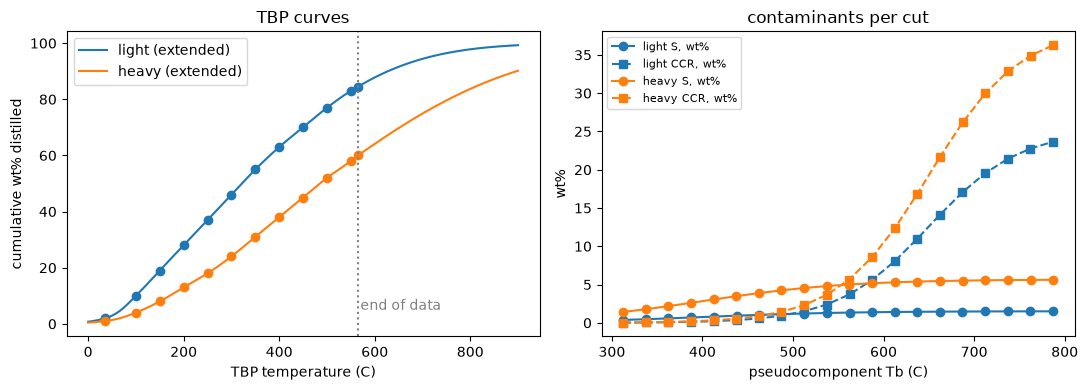

In [2]:
crudes = {"light": dr.light_crude(), "heavy": dr.heavy_crude()}
chars = {k: dr.characterize(a) for k, a in crudes.items()}

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
T = np.linspace(0, 900, 400)
for k, a in crudes.items():
    line, = ax[0].plot(T, 100 * dr.tbp_fraction(a, T), label=f"{k} (extended)")
    ax[0].plot(a.tbp_C, a.tbp_wt, "o", color=line.get_color())
    c = chars[k].components
    ax[1].plot(c.Tb[:-1] - C, 100 * c.sulfur[:-1], "o-", color=line.get_color(), label=f"{k} S, wt%")
    ax[1].plot(c.Tb[:-1] - C, 100 * c.ccr[:-1], "s--", color=line.get_color(), label=f"{k} CCR, wt%")
ax[0].axvline(565, color="gray", ls=":")
ax[0].text(570, 5, "end of data", color="gray")
ax[0].set(xlabel="TBP temperature (C)", ylabel="cumulative wt% distilled", title="TBP curves")
ax[0].legend()
ax[1].set(xlabel="pseudocomponent Tb (C)", ylabel="wt%", title="contaminants per cut")
ax[1].legend(fontsize=8)
plt.tight_layout()

c = chars["heavy"].components
print(f"{'cut':>12} {'Tb C':>7} {'SG':>6} {'MW':>7} {'Tc C':>7} {'Pc bar':>7} {'omega':>6}")
for i in range(0, c.n, 4):
    print(f"{c.names[i]:>12} {c.Tb[i]-C:7.1f} {c.SG[i]:6.3f} {c.MW[i]:7.1f} "
          f"{c.Tc[i]-C:7.1f} {c.Pc[i]/1e5:7.2f} {c.omega[i]:6.3f}")

## 2. Feed and column

The feed is 370 C+ residue from 100 kg/s of crude. The column has LVGO and
HVGO pumparound beds, a wash bed with the slop drawn below it, the flash zone
and two stripping stages, and runs at 10 mmHg top and 30 mmHg flash zone. The
default specs hold the top at 70 C (through the LVGO pumparound duty), the
overflash at 3% of feed (through the HVGO draw) and the LVGO end point at
450 C (through the HVGO pumparound duty). That leaves the furnace outlet
temperature, the flash-zone pressure and the stripping steam as the levers.

In [3]:
char = chars["heavy"]
feed = dr.atmospheric_residue(char, crude_rate_kg_s=100.0)
params = dr.VacuumColumnParams(components=char.components)
vdu = dr.VacuumColumn(params)

overhead, lvgo, hvgo, slop, residue, info = vdu(feed)
print("converged:", bool(info["converged"]), "in", int(info["iterations"]), "Newton iterations")

out, props = info["outputs"], info["properties"]
print(f"\nfeed {float(out['feed.rate']):.1f} kg/s; furnace duty {float(out['furnace.duty'])/1e6:.1f} MW, "
      f"{100*float(out['furnace.vapor_fraction']):.0f}% vaporized at the coil outlet\n")
print(f"{'':8} {'kg/s':>6} {'yield':>6} {'T05':>6} {'T50':>6} {'T95':>6} {'SG':>6} {'S%':>5} {'CCR%':>5} {'Ni+V':>6}")
for n in ("lvgo", "hvgo", "slop", "residue"):
    p = props[n]
    print(f"{n:8} {float(p['rate']):6.2f} {float(p['rate']/out['feed.rate']):6.3f} "
          f"{float(p['T05'])-C:6.0f} {float(p['T50'])-C:6.0f} {float(p['T95'])-C:6.0f} "
          f"{float(p['sg']):6.3f} {float(p['sulfur_wt']):5.2f} {float(p['ccr_wt']):5.2f} "
          f"{float(p['nickel_vanadium_wppm']):6.1f}")

converged: True in 6 Newton iterations

feed 66.2 kg/s; furnace duty 13.1 MW, 30% vaporized at the coil outlet

           kg/s  yield    T05    T50    T95     SG    S%  CCR%   Ni+V
lvgo       4.66  0.070    350    391    450  0.909  2.73  0.29    0.0
hvgo      19.61  0.296    391    473    566  0.944  3.98  1.84    1.0
slop       1.99  0.030    496    595    834  0.999  5.14 12.93  100.2
residue   39.94  0.603    559    753    888  1.054  5.50 28.43  494.9


largest relative mass-balance error over the pseudocomponents: 2.366278929706582e-15


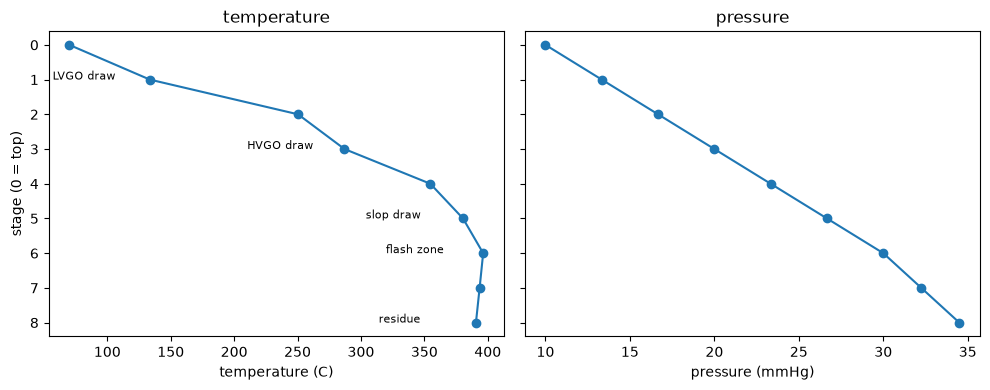

In [4]:
prof = info["profiles"]
stage = np.arange(len(prof["T"]))
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax[0].plot(np.asarray(prof["T"]) - C, stage, "o-")
ax[0].set(xlabel="temperature (C)", ylabel="stage (0 = top)", title="temperature")
ax[1].plot(np.asarray(prof["P"]) / 133.322, stage, "o-")
ax[1].set(xlabel="pressure (mmHg)", title="pressure")
ax[0].invert_yaxis()
labels = {1: "LVGO draw", 3: "HVGO draw", 5: "slop draw", 6: "flash zone", 8: "residue"}
for j, s in labels.items():
    ax[0].annotate(s, (float(prof["T"][j]) - C, j), textcoords="offset points", xytext=(-70, 0), fontsize=8)
plt.tight_layout()

# per pseudocomponent mass balance
names = char.components.names
f = np.array([float(feed[f"F_{n}"]) for n in names])
prod = sum(np.array([float(s[f"F_{n}"]) for n in names]) for s in (overhead, lvgo, hvgo, slop, residue))
print("largest relative mass-balance error over the pseudocomponents:", np.max(np.abs(prod - f) / f))

## 3. VGO yield against furnace temperature, with its gradient

Each point below is a full column solve, and each slope is `jax.value_and_grad`
of that solve. The gradient comes from the implicit-function theorem at the
converged MESH equations, `-J^-1 dR/dT`. It costs one linear solve with a
Jacobian the Newton loop already has, and it never differentiates the
iterations. The dashed lines are those slopes drawn as tangents. The finite
differences of the sweep are shown as a check.

The cracking limit (415 C) is reported, not imposed: past it the column still
solves, and warns, so the trade-off between lift and cracking stays visible.

d(VGO yield)/dT at 400 C: 0.2637 % of feed per K


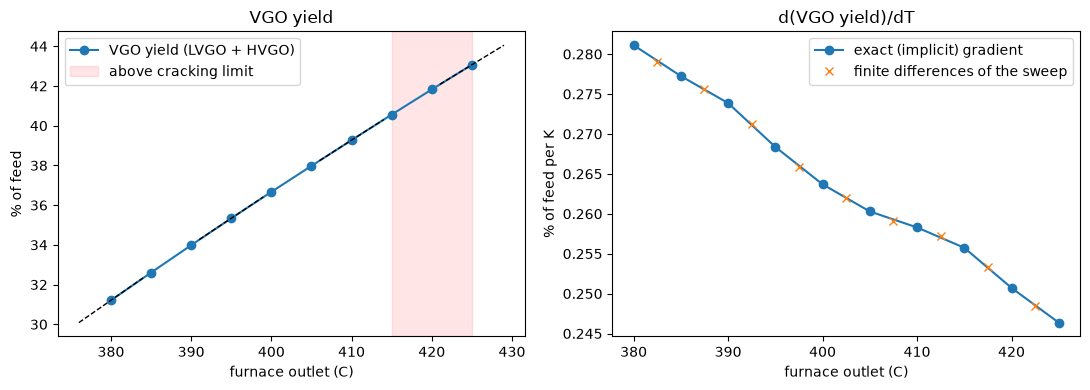

In [5]:
import warnings

def vgo_yield(T_furnace):
    out = dr.VacuumColumn(params.update(furnace_T=T_furnace))(feed)[-1]["outputs"]
    return out["vgo.yield"]

vg = jax.jit(jax.value_and_grad(vgo_yield))
Ts = np.linspace(380.0, 425.0, 10)
vals, grads = [], []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", dr.CrackingWarning)
    for t in Ts:
        v, g = vg(t + C)
        vals.append(float(v)); grads.append(float(g))
vals, grads = np.array(vals), np.array(grads)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ts, 100 * vals, "o-", label="VGO yield (LVGO + HVGO)")
for t, v, g in zip(Ts[::3], vals[::3], grads[::3]):
    dt = np.array([-4, 4])
    ax[0].plot(t + dt, 100 * (v + g * dt), "k--", lw=1)
ax[0].axvspan(415, 425, color="red", alpha=0.1, label="above cracking limit")
ax[0].set(xlabel="furnace outlet (C)", ylabel="% of feed", title="VGO yield")
ax[0].legend()
mid = 0.5 * (Ts[1:] + Ts[:-1])
ax[1].plot(Ts, 100 * grads, "o-", label="exact (implicit) gradient")
ax[1].plot(mid, 100 * np.diff(vals) / np.diff(Ts), "x", label="finite differences of the sweep")
ax[1].set(xlabel="furnace outlet (C)", ylabel="% of feed per K", title="d(VGO yield)/dT")
ax[1].legend()
plt.tight_layout()
print("d(VGO yield)/dT at 400 C: %.4f %% of feed per K" % (100 * float(vg(400.0 + C)[1])))

## 4. The HVGO quality a planner sees

The conversion unit downstream cares about how heavy and how dirty the HVGO is,
not just how much there is. Every one of these properties has a gradient with
respect to every lever, and with respect to the assay itself. The last column
is the sensitivity to one point of the TBP curve, the 500 C point. That is
the question to ask when a new assay of the same crude comes back a few
degrees different.

In [6]:
keys = ["T95", "sg", "sulfur_wt", "nitrogen_wppm", "ccr_wt", "nickel_vanadium_wppm"]

def hvgo_quality(levers):
    p = params.update(furnace_T=levers[0], flash_zone_P=levers[1], steam_rate=levers[2])
    q = dr.VacuumColumn(p)(feed)[-1]["properties"]["hvgo"]
    return jnp.stack([q[k] for k in keys])

x0 = jnp.array([400.0 + C, 4000.0, 0.33])
J = jax.jacfwd(hvgo_quality)(x0)

crude = crudes["heavy"]
def hvgo_quality_vs_assay(t500):
    ch = dr.characterize(crude.with_tbp_point(9, t500))
    fd = dr.atmospheric_residue(ch, crude_rate_kg_s=100.0)
    q = dr.VacuumColumn(params.update(components=ch.components))(fd)[-1]["properties"]["hvgo"]
    return jnp.stack([q[k] for k in keys])

Ja = jax.jacfwd(hvgo_quality_vs_assay)(500.0)

print(f"{'HVGO':>22} {'per K furnace':>14} {'per kPa flash zone':>19} {'per kg/s steam':>15} {'per K of TBP@500':>17}")
for i, k in enumerate(keys):
    print(f"{k:>22} {float(J[i,0]):14.4g} {1e3*float(J[i,1]):19.4g} {float(J[i,2]):15.4g} {float(Ja[i]):17.4g}")

                  HVGO  per K furnace  per kPa flash zone  per kg/s steam  per K of TBP@500
                   T95         0.9983              -6.774           18.02            0.3018
                    sg      0.0002939           -0.002355        0.007231         0.0004181
             sulfur_wt       0.008874            -0.07272          0.2255          0.006683
         nitrogen_wppm          16.55              -130.1           400.7             13.17
                ccr_wt        0.03158             -0.2294          0.6705           0.02762
  nickel_vanadium_wppm       0.006454            -0.05192           0.121           0.01394


## 5. Turning the question around with a spec

Every knob can be traded for a target on any output. Here the furnace outlet
temperature becomes an unknown, and the HVGO end point (TBP 95%) is held
instead. One solve then answers the question: what furnace temperature does
a 575 C HVGO end point cost, and how close is it to the cracking limit?

In [7]:
specs = dr.default_vacuum_specs() + (
    dr.Spec("hvgo.T95", 575.0 + C, replaces="furnace.T"),)
info2 = dr.VacuumColumn(params.update(specs=specs))(feed)[-1]
o2 = info2["outputs"]
print("converged:", bool(info2["converged"]))
print(f"furnace outlet needed: {float(o2['furnace.T']) - C:.1f} C "
      f"(cracking margin {float(o2['furnace.cracking_margin']):.1f} K)")
print(f"HVGO {float(o2['hvgo.rate']):.2f} kg/s, residue yield {float(o2['residue.yield']):.3f}")

converged: True
furnace outlet needed: 409.6 C (cracking margin 5.4 K)
HVGO 21.07 kg/s, residue yield 0.578


## Where this stops

- `atmospheric_residue` is an idealized CDU cut; a `CrudeColumn` on the same
  stage-network machinery would replace it without changing anything here.
- K-values are ideal (`psat/P`), which a vacuum column makes reasonable; the
  correlations, not the ideality, set the accuracy.
- There is no cross-check against an independent simulator (DWSIM or IDAES) yet.
- Ejectors, dynamics and lube towers are out of scope.

See `docs/unit-operations-refinery.md`.